# CREATE A COPY FIRST!

## **Question 2: Arabic Handwritten Character Search**

Ali’s younger brother is learning to write Arabic characters. One day, he wrote a character that looks like **"ب"**, and Ali wants to find **the most similar 5 images** from a dataset of handwritten Arabic characters.

📝 **Your Task:**  
Complete the missing code cells below by implementing **image search** to find the most similar 5 images to the given input character.  



# Download Data

### Query Image

In [1]:
# # Please uncomment this out when you are running this lab on google colab!
import os

# # Set KaggleHub cache to a directory inside /content/
os.environ["KAGGLEHUB_CACHE"] = "/content/data"

100%|██████████| 320/320 [00:00<00:00, 153kB/s]

Extracting files...


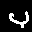

In [2]:
import kagglehub
from PIL import Image
import os

path = kagglehub.dataset_download("mohammad2012191/character")
raw_query_image = Image.open(os.path.join(path,"char.png"))
raw_query_image

### Arabic Characters Dataset

In [3]:
import kagglehub

# Download latest version
dataset_path = kagglehub.dataset_download("mohammad2012191/arabic-chars")

print("Path to dataset files:", dataset_path)

100%|██████████| 219k/219k [00:00<00:00, 58.1MB/s]

Extracting files...
Path to dataset files: /content/data/datasets/mohammad2012191/arabic-chars/versions/3


# TASK 1: Complete the following code to build a custom dataset class for the data

In [16]:
import os
from glob import glob
from PIL import Image
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms

class ArabicHandwritingDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.image_paths = glob("/content/data/datasets/mohammad2012191/arabic-chars/versions/3/chars images/*.png") # TO DO: Use glob to extract images paths from root_dir
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        image = Image.open(img_path).convert("RGB") ########################### TO DO: Write a line to load the image from img_path
        label = img_path.split("/")[-1].split("_")[0] ########################### TO DO: Write a line to extract the label from img_path
        if self.transform:
            image = self.transform(image)
        return image, label

In [14]:
transform = transforms.Compose([
    transforms.Grayscale(3),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ########################### TO DO: Resize to 32*32
    ########################### TO DO: Convert to Tensor
    ########################### TO DO: Normalize using Imagenet mean and std
])


train_dataset = ArabicHandwritingDataset(root_dir=os.path.join(dataset_path,"chars images"), transform=transform)
batch_size = 64
train_loader = DataLoader(train_dataset, batch_size, shuffle=False, num_workers=2)

  ########################### TO DO
print(f"Total images: {len(train_dataset)}")


from PIL import Image
import numpy as np
transformed_query_image = np.asarray(train_loader)########################### TO DO: Apply the transform to raw_query_image

Total images: 668


# TASK 2: Use EfficientNet B3 to extract features.

##### import using:
from torchvision.models import efficientnet_b3

### Extract Features for the dataset images

In [23]:
# TO DO: Load pretrained efficientnet_b3 model
import torch
import torchvision.models as models
from torch import nn
from tqdm import tqdm

# Load pretrained efficientnet_b3 model
device = "cuda" if torch.cuda.is_available() else "cpu"
efficientnet = models.efficientnet_b3(pretrained=True).to(device)
efficientnet.eval().to(device)

# TO DO: Use efficientnet_b3 to extract features

# Modify efficientnet_b3 to extract features before classification
def extract_features(image_tensor):
    image_tensor = image_tensor.to(device)
    with torch.no_grad():
        features = efficientnet.features(image_tensor)  # Extract features هنا لازم نطبع المودل لحاله وندور للاسم اللي قبل سيكونشل عشان نبغى نستخرج الفيتشرز بدون الكلاسفاير (اخر لاير بعد ما طبعنا الارتشكتشر حق المودل لقينا اسمها فيتشرز فكتبنا اسمه دوت فيتشرز)
        features = torch.flatten(features, start_dim=1)  # Flatten before passing to classifier
        # features = efficientnet.classifier[0](features)  # Pass through first layer of classifier
    return features

# Extract features for all images
all_features = []
image_tensors = []

for images, _ in tqdm(train_loader):
    image_tensors.append(images)
    features = extract_features(images)
    all_features.append(features.cpu())
# TO DO: Convert features to numpy and concatenate them.
# Convert to numpy
all_features = torch.cat(all_features).numpy()
# TO DO: Concatenate the raw images tensors
image_tensors = torch.cat(image_tensors)


100%|██████████| 11/11 [02:25<00:00, 13.19s/it]


### Extract Features for the query image

In [26]:
from sklearn.decomposition import PCA

# Apply PCA
n_pca_components = 300  # Number of principal components to keep (reduce the dimintion)
pca = PCA(n_components=n_pca_components)
pca_features = pca.fit_transform(all_features)

# TASK 3: Get the indices of top 5 images using Cosine Similarity

In [30]:
### TO DO
from sklearn.metrics.pairwise import cosine_similarity
import random
# Select a random query image
random_idx = random.randint(0, len(pca_features) - 1)
query_image = image_tensors[random_idx]
query_features = pca_features[random_idx]

# Compute cosine similarity
similarities = cosine_similarity(pca_features, query_features.reshape(1, -1)).reshape(-1)

# Get top 5 similar images
top_indices = similarities.argsort()[-6:-1][::-1]  # Ignore query itself (here its sort the number from samll to big then [::-1] sort from big to small)

# TASK 4: Fix the errors in the following code to plot the most 5 similar images

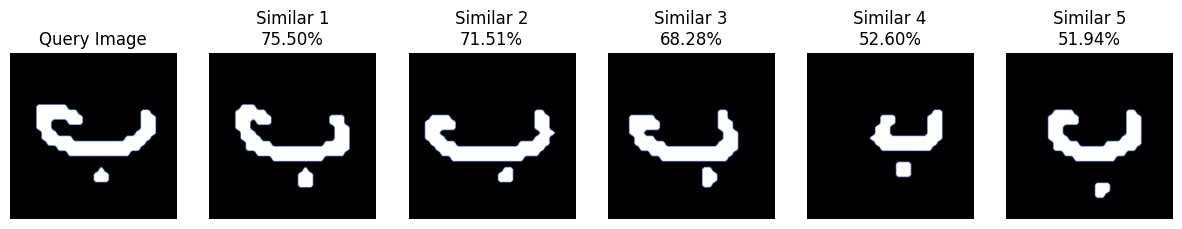

In [35]:
# Display query & retrieved images with similarity scores
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 6, figsize=(15, 3))

# Query image
axes[0].imshow(query_image.permute(1, 2, 0).numpy())
axes[0].set_title("Query Image")
axes[0].axis("off")

# Retrieved similar images with similarity scores
for i, idx in enumerate(top_indices):
    image = image_tensors[idx]
    similarity_score = similarities[idx]  # Get similarity score
    axes[i + 1].imshow(image.permute(1, 2, 0).numpy())
    axes[i + 1].set_title(f"Similar {i+1}\n{100*similarity_score:.2f}%")  # Show similarity score
    axes[i + 1].axis("off")

plt.show()


# Bonus Task:  Get the indices of the most 5 *dissimilar* images and plot them

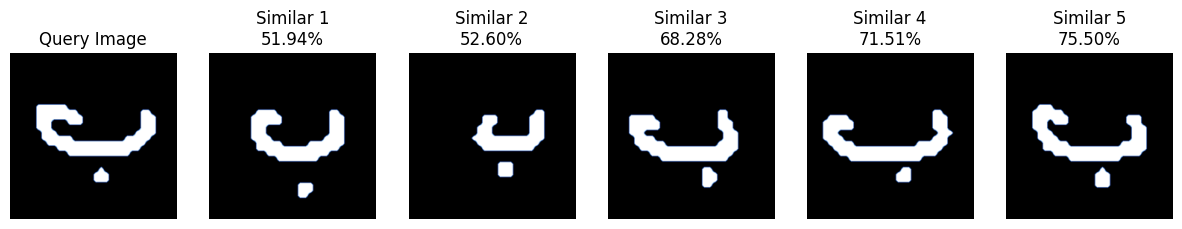

In [41]:
### TO DO
less_indices = similarities.argsort()[:]  # Ignore query itself (here its sort the number from samll to big then [::-1] sort from big to small)
# Display query & retrieved images with similarity scores
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 6, figsize=(15, 3))

# Query image
axes[0].imshow(query_image.permute(1, 2, 0).numpy())
axes[0].set_title("Query Image")
axes[0].axis("off")

# Retrieved similar images with similarity scores
for i, idx in enumerate(top_indices):
    image = image_tensors[idx]
    similarity_score = similarities[idx]  # Get similarity score
    axes[i + 1].imshow(image.permute(1, 2, 0).numpy())
    axes[i + 1].set_title(f"Similar {i+1}\n{100*similarity_score:.2f}%")  # Show similarity score
    axes[i + 1].axis("off")

plt.show()
